In [ ]:
# Add only your imports here
import csv
import networkx as nx
import matplotlib.pyplot as plt
from collections import deque
import heapq
import math

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Assume that the data files are in the following folder -- THIS WILL BE USED BY THE TA
basePath = "/content/drive/My Drive/Colab Notebooks/Artificial Intelligence/Data/"
cities_file = basePath + "cities.csv"
distances_file = basePath + "distances.csv"

In [ ]:
# Load the graph data from the files
G = nx.Graph()

# load cities (nodes)
with open(cities_file, 'r') as file:
    reader = csv.reader(file)

    for row in reader:
        city = row[0].strip()
        lat = float(row[1])
        lon = float(row[2])

        G.add_node(city, pos=((lon), (lat)))

# load distances (edges)
with open(distances_file, 'r') as file:
    reader = csv.reader(file)

    for row in reader:
        city1 = row[0].strip()
        city2 = row[1].strip()
        distance = float(row[2])

        G.add_edge(city1, city2, weight=distance)

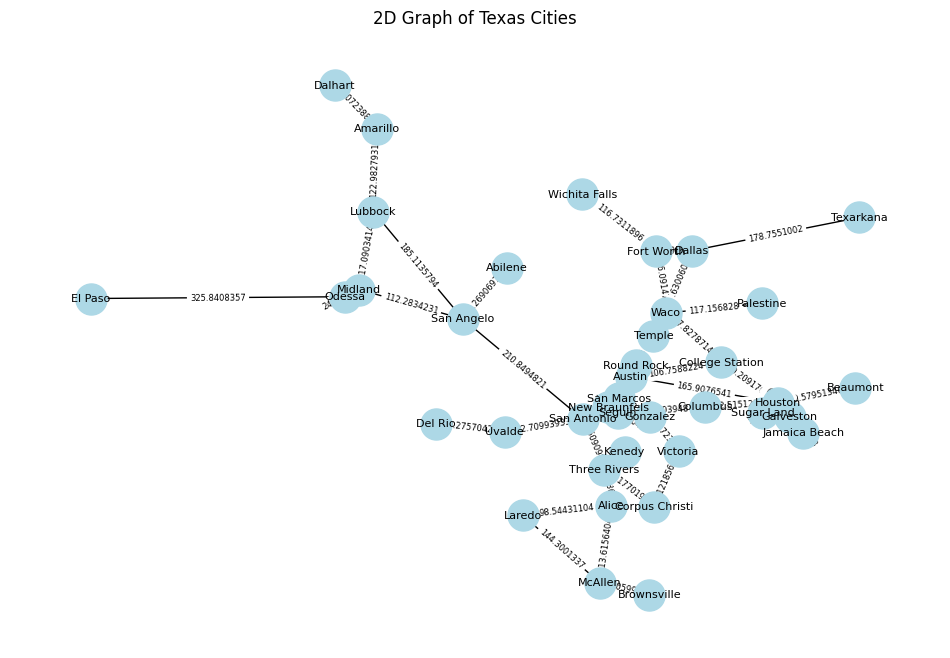

In [ ]:
# Display a 2D graph of the given data.

# get positions from node attributes
pos = nx.get_node_attributes(G, 'pos')

# create figure
plt.figure(figsize=(12,8))

# draw nodes
nx.draw_networkx_nodes(G, pos, node_size=500, node_color='lightblue')

# draw edges
nx.draw_networkx_edges(G, pos, width=1)

# draw labels
nx.draw_networkx_labels(G, pos, font_size=8)

# draw edge weights
edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=6)

plt.title("2D Graph of Texas Cities")
plt.axis("off")
plt.show()

In [ ]:
print(G.nodes["El Paso"]["pos"])

(-106.4309, 31.8479)


In [ ]:
def bfs_virus_spread(G, start):
    visited_cities = set()
    cities_queue = deque([start])
    spread_order = []      # tracks infection order
    total_distance = 0

    while cities_queue:
        city = cities_queue.popleft()

        if city not in visited_cities:
            visited_cities.add(city)
            spread_order.append(city)

            for neighbor in G.neighbors(city):
                if neighbor not in visited_cities:
                    cities_queue.append(neighbor)
                    total_distance += G[city][neighbor]['weight']

    return spread_order, total_distance

start_city = "Three Rivers"

path, total_distance = bfs_virus_spread(G, start_city)

print("The path / sequence of infected cities:")
for city in path:
    print(city)

print("\nTotal distance travelled:", total_distance)

The path / sequence of infected cities:
Three Rivers
San Antonio
Corpus Christi
Alice
Kenedy
San Angelo
New Braunfels
Seguin
Uvalde
Victoria
Laredo
McAllen
Midland
Lubbock
Abilene
San Marcos
Gonzalez
Columbus
Del Rio
Brownsville
Odessa
Amarillo
Austin
Houston
El Paso
Dalhart
Round Rock
College Station
Beaumont
Galveston
Sugar Land
Temple
Waco
Jamaica Beach
Palestine
Fort Worth
Dallas
Wichita Falls
Texarkana

Total distance travelled: 4073.6619521799994


In [ ]:
import heapq
import math

def heuristic(G, current_city, goal_city):
    x1, y1 = G.nodes[current_city]['pos']
    x2, y2 = G.nodes[goal_city]['pos']
    return math.sqrt((x1 - x2)**2 + (y1 - y2)**2)


def a_star_search(G, start_city, goal_city):

    priority_queue = []
    heapq.heappush(priority_queue, (0, start_city))

    came_from = {}
    g_cost = {start_city: 0}
    visited = set()

    while priority_queue:
        _, current = heapq.heappop(priority_queue)

        if current in visited:
            continue

        visited.add(current)

        if current == goal_city:
            break

        for neighbor in G.neighbors(current):
            weight = G[current][neighbor]['weight']
            tentative_g = g_cost[current] + weight

            if neighbor not in g_cost or tentative_g < g_cost[neighbor]:
                g_cost[neighbor] = tentative_g

                f_cost = tentative_g + heuristic(G, neighbor, goal_city)

                heapq.heappush(priority_queue, (f_cost, neighbor))

                came_from[neighbor] = current

    # reconstruct path
    path = []
    node = goal_city

    while node in came_from:
        path.append(node)
        node = came_from[node]

    path.append(start_city)
    path.reverse()

    return path, g_cost.get(goal_city, float('inf'))

start_city = "San Antonio"
goal_city = "College Station"

path, total_distance = a_star_search(G, start_city, goal_city)

print("Optimal vaccine transportation path:")
for city in path:
    print(city)

print("\nTotal distance travelled:", total_distance)

Optimal vaccine transportation path:
San Antonio
New Braunfels
San Marcos
Austin
College Station

Total distance travelled: 186.77450141
